# Analysis

Sentiment, categorization, clustering, and Plotly exploration for discovery records.

Section 1 runs `extract_records.run()` to build `output/processed/challenges.csv` and `expectations.csv` from source notes/worksheets (no terminal step needed).


In [1]:
from pathlib import Path

def _requirements() -> Path:
    """Find simple/requirements.txt whether kernel cwd is simple/ or notebook/."""
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        req = candidate / "requirements.txt"
        if req.is_file() and (candidate / "scripts").is_dir():
            return req
    raise FileNotFoundError(
        "Could not find requirements.txt next to scripts/. "
        f"cwd={here}"
    )

%pip install -q -r {_requirements()}
%pip install -q "nbformat>=4.2.0"


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# 0. Import Libraries

In [2]:
from pathlib import Path
import os
import sys

import hdbscan
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import umap
from IPython.display import Markdown, display
from sklearn.metrics import silhouette_score

# Resolve project root (simple/) whether the kernel cwd is simple/ or notebook/
def _project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / "scripts" / "sentiment_analysis.py").is_file():
            return candidate
    raise FileNotFoundError(
        "Could not find project root (expected scripts/sentiment_analysis.py). "
        f"cwd={here}"
    )


ROOT = _project_root()
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.categorize_records import CATEGORY_CONFIG, CATEGORY_DESCRIPTIONS, run_categorize
from scripts.extract_records import SOURCE_MEETING_NOTES, load_prepared_records, run
from scripts.sentiment_analysis import realign_by_sentiment, run_sentiment

PROCESSED_DIR = ROOT / "output" / "processed"
CHALLENGES_CSV = PROCESSED_DIR / "challenges.csv"
EXPECTATIONS_CSV = PROCESSED_DIR / "expectations.csv"

CHALLENGES_SCORED = PROCESSED_DIR / "challenges_scored.csv"
EXPECTATIONS_SCORED = PROCESSED_DIR / "expectations_scored.csv"
CATEGORIZED_CHALLENGES_CSV = PROCESSED_DIR / "categorized_challenges.csv"
CATEGORIZED_EXPECTATIONS_CSV = PROCESSED_DIR / "categorized_expectations.csv"
CATEGORY_SUMMARY_CSV = PROCESSED_DIR / "category_summary.csv"
CATEGORY_SUMMARY_XLSX = PROCESSED_DIR / "category_summary.xlsx"

CHALLENGE_TEXT_COL = "pain_points"
EXPECTATION_TEXT_COL = "expectations"


## 1. Extract, load & prep records

Runs `run()` to extract from source notes/worksheets into CSVs, then `load_prepared_records()` (focus-group aliases, source tags, short meeting-note merge).


In [3]:
run()  # writes output/processed/challenges.csv and expectations.csv
df_painpoints, df_expectations = load_prepared_records(
    CHALLENGES_CSV, EXPECTATIONS_CSV
)

print(f"Challenges: {len(df_painpoints)} | Expectations: {len(df_expectations)}")
print(df_painpoints["source"].value_counts().to_string())


=== 1. Directories ===
  RAW_DIR       → /Users/lilscott/Code/IPS/output/raw
  PROCESSED_DIR → /Users/lilscott/Code/IPS/output/processed
  SECTIONS_DIR  → /Users/lilscott/Code/IPS/output/raw/docx_sections

=== 2. Split discovery notes ===
  Saved: Admin Aide.docx (Admin Aide)
  Saved: Building Inspectors.docx (Building Inspectors)
  Merged: Admin Aide.docx (Admin Aide)
  Saved: Supervisors.docx (Supervisors)
  Saved: Housing Inspectors.docx (Housing Inspectors)
  Saved: Permit_Commercial_Electrical Inspectors.docx (Permit/Commercial/Electrical Inspectors)
  Saved: Fire.docx (Fire)
  Saved: Permits.docx (Permits)
  Saved: Zoning.docx (Zoning)
  Saved: Office Managers.docx (Office Managers)
  Saved: CPO-Coordinators.docx (CPO-Coordinators)
  Saved: Law.docx (Law)
  Saved: Assessment.docx (Assessment)
  Saved: BAA Supervisors.docx (BAA Supervisors)
  Saved: NBD Internal.docx (NBD Internal)
  Saved: CPC.docx (CPC)
  Saved: NBD Data Team.docx (NBD Data Team)
  Merged: BAA Supervisors.docx (

In [4]:
df_painpoints.sample(10)

,department,focus_group,pain_points,source,processed_text
429,BAA,BAA ALJs,e.g. RR failure to apply/obtain - many cases,meeting_notes,e.g. RR failure to apply/obtain - many cases
1103,DOCE,Supervisors,Older system – missed assignment run – could r...,meeting_notes,Older system – missed assignment run – could r...
119,DOCE,Building Inspectors,Crashing at least thrice a week,worksheet,Crashing at least thrice a week
986,DOCE,Permit/Commercial/Electrical Inspectors,Told by vendor they could do periodic inspecti...,meeting_notes,Told by vendor they could do periodic inspecti...
1038,CPO,Permits,Two versions of the same case,meeting_notes,Two versions of the same case
1002,DOCE,Permit/Commercial/Electrical Inspectors,Notifications via email but difficult to case ...,meeting_notes,Notifications via email but difficult to case ...
1138,DOCE,Supervisors,Needs to be user-friendly – Camino is an app b...,meeting_notes,Needs to be user-friendly – Camino is an app b...
511,BAA,BAA Supervisors,Outlook for scheduling Outlook for communicati...,meeting_notes,Outlook for scheduling Outlook for communicati...
255,NBD,NBD Data Team,"Leak of standardized / consistent data entry, ...",worksheet,"Leak of standardized / consistent data entry, ..."
347,DOCE,Admin Aide,Computer is slow – takes 45 sec to open compla...,meeting_notes,Computer is slow – takes 45 sec to open compla...


## 2. Sentiment Analysis

Uses `Thi144/sentiment-distilbert-7class`, mapped to negative / neutral / positive.


In [5]:
df_painpoints, df_expectations = run_sentiment(df_painpoints, df_expectations)

print("Pain sentiment:\n", df_painpoints["sentiment"].value_counts().to_string())
print("\nExpectation sentiment:\n", df_expectations["sentiment"].value_counts().to_string())

df_painpoints.to_csv(CHALLENGES_SCORED, index=False, encoding="utf-8-sig")
df_expectations.to_csv(EXPECTATIONS_SCORED, index=False, encoding="utf-8-sig")
print(f"Saved → {CHALLENGES_SCORED.name}, {EXPECTATIONS_SCORED.name}")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Scoring challenges with distilbert-base-uncased-finetuned-sst-2-english + context wrappers…
Scoring expectations…
Pain sentiment:
 sentiment
negative    1168
positive      43

Expectation sentiment:
 sentiment
negative    273
positive    207
Saved → challenges_scored.csv, expectations_scored.csv


In [ ]:

retriever = run_categorize(df_painpoints, df_expectations)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

## 3. Realign misclassified rows

Move positive “pain” → expectations and negative “expectations” → pain, **meeting_notes only**.


In [7]:
# Find positive pain points where source is meeting_notes
df_painpoints.loc[
    (df_painpoints["sentiment"] == "positive")
    & (df_painpoints["source"] == SOURCE_MEETING_NOTES)
]


,department,focus_group,pain_points,source,processed_text,sentiment
340,DOCE,Admin Aide,"Appreciates that within parcel, can click on b...",meeting_notes,"Appreciates that within parcel, can click on b...",positive
341,DOCE,Admin Aide,Dark mode for IPS? +2 Incredibly bright,meeting_notes,Dark mode for IPS? +2 Incredibly bright,positive
363,DOCE,Admin Aide,Everything else runs pretty smoothly – mainly ...,meeting_notes,Everything else runs pretty smoothly – mainly ...,positive
375,DOCE,Admin Aide,Technology Features you like/that work well,meeting_notes,Technology Features you like/that work well,positive
376,DOCE,Admin Aide,Likes periodics window for Rental Registry,meeting_notes,Likes periodics window for Rental Registry,positive
440,BAA,BAA Operations,Ability to organize by action type or departme...,meeting_notes,Ability to organize by action type or departme...,positive
441,BAA,BAA Operations,Very detailed within info to put int,meeting_notes,Very detailed within info to put int,positive
458,BAA,BAA Operations,Likes notes tab – nice that it's separate from...,meeting_notes,Likes notes tab – nice that it's separate from...,positive
459,BAA,BAA Operations,Likes how detailed the info we can input is – ...,meeting_notes,Likes how detailed the info we can input is – ...,positive
460,BAA,BAA Operations,Likes when they search that you can see what's...,meeting_notes,Likes when they search that you can see what's...,positive


In [8]:
n_pos = int(
    ((df_painpoints["source"] == SOURCE_MEETING_NOTES) & (df_painpoints["sentiment"] == "positive")).sum()
)
n_neg = int(
    ((df_expectations["source"] == SOURCE_MEETING_NOTES) & (df_expectations["sentiment"] == "negative")).sum()
)

df_painpoints, df_expectations = realign_by_sentiment(
    df_painpoints, df_expectations, only_source=SOURCE_MEETING_NOTES
)

print(f"Moved meeting_notes only: {n_pos} positive→expectations, {n_neg} negative→pain")
print(f"Shapes: pain {len(df_painpoints)}, expectations {len(df_expectations)}")
print(df_painpoints["source"].value_counts().to_string())


Moved meeting_notes only: 42 positive→expectations, 123 negative→pain
Shapes: pain 1292, expectations 399
source
meeting_notes    995
worksheet        297


## 3b. Validate sentiment after realignment

Confirm meeting-note positives no longer sit in challenges and negatives no longer sit in expectations, then chart the post-realign mix.


Post-realign validation (meeting_notes only)
  Positive challenges remaining: 0 (expect 0)
  Negative expectations remaining: 0 (expect 0)
  OK — no meeting_notes polarity mismatches left in the wrong table.

Sentiment counts after realign:
  Challenges: {'negative': 1291, 'neutral': 0, 'positive': 1}
  Expectations: {'negative': 150, 'neutral': 0, 'positive': 249}
Saved /Users/lilscott/Code/IPS/output/figures/sentiment_mix_post_realign.png


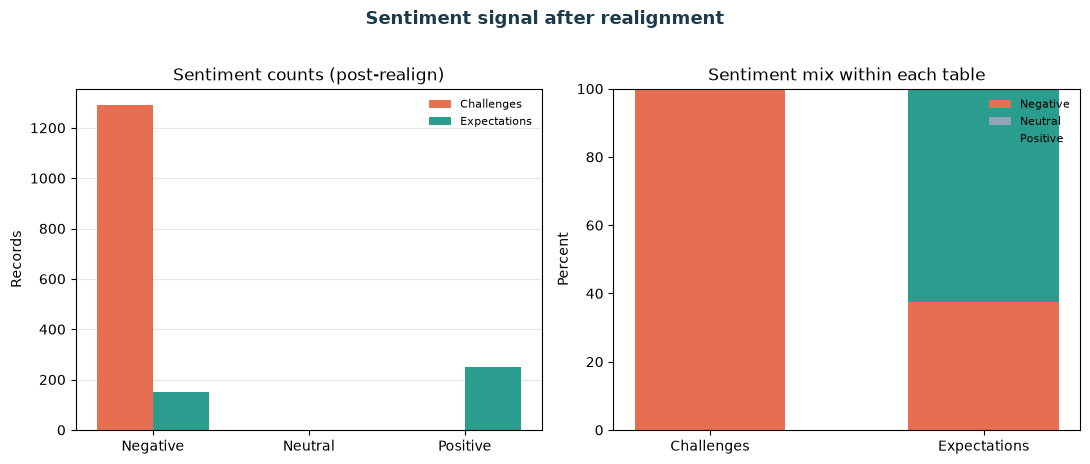

In [9]:
CORAL = "#E76F51"
TEAL = "#2A9D8F"
MUTED = "#94A3B8"
NAVY = "#1B3A4B"

order = ["negative", "neutral", "positive"]
colors = {"negative": CORAL, "neutral": MUTED, "positive": TEAL}


def counts(frame: pd.DataFrame) -> list[int]:
    vc = frame["sentiment"].value_counts()
    return [int(vc.get(s, 0)) for s in order]


def pct(vals: list[int]) -> list[float]:
    total = sum(vals) or 1
    return [100 * v / total for v in vals]


# --- Validation: realign should clear these meeting_notes mismatches ---
pos_in_challenges = df_painpoints.loc[
    (df_painpoints["source"] == SOURCE_MEETING_NOTES)
    & (df_painpoints["sentiment"] == "positive")
]
neg_in_expectations = df_expectations.loc[
    (df_expectations["source"] == SOURCE_MEETING_NOTES)
    & (df_expectations["sentiment"] == "negative")
]

print("Post-realign validation (meeting_notes only)")
print(f"  Positive challenges remaining: {len(pos_in_challenges)} (expect 0)")
print(f"  Negative expectations remaining: {len(neg_in_expectations)} (expect 0)")
if len(pos_in_challenges) or len(neg_in_expectations):
    display(Markdown("**Still misfiled after realign — inspect below**"))
    if len(pos_in_challenges):
        display(pos_in_challenges)
    if len(neg_in_expectations):
        display(neg_in_expectations)
else:
    print("  OK — no meeting_notes polarity mismatches left in the wrong table.")

print("\nSentiment counts after realign:")
print("  Challenges:", dict(zip(order, counts(df_painpoints))))
print("  Expectations:", dict(zip(order, counts(df_expectations))))

ch, ex = counts(df_painpoints), counts(df_expectations)
x = np.arange(len(order))
w = 0.36

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(x - w / 2, ch, width=w, color=CORAL, label="Challenges")
axes[0].bar(x + w / 2, ex, width=w, color=TEAL, label="Expectations")
axes[0].set_xticks(x)
axes[0].set_xticklabels([s.title() for s in order])
axes[0].set_ylabel("Records")
axes[0].set_title("Sentiment counts (post-realign)")
axes[0].legend(frameon=False, fontsize=8)
axes[0].set_axisbelow(True)
axes[0].yaxis.grid(True, color="#E2E8F0", lw=0.8)

ch_p, ex_p = pct(ch), pct(ex)
bottom = np.zeros(2)
for i, sent in enumerate(order):
    vals = [ch_p[i], ex_p[i]]
    axes[1].bar(
        ["Challenges", "Expectations"],
        vals,
        bottom=bottom,
        color=colors[sent],
        label=sent.title(),
        width=0.55,
    )
    bottom = bottom + vals
axes[1].set_ylim(0, 100)
axes[1].set_ylabel("Percent")
axes[1].set_title("Sentiment mix within each table")
axes[1].legend(frameon=False, fontsize=8, loc="upper right")

fig.suptitle(
    "Sentiment signal after realignment",
    fontsize=13,
    fontweight="bold",
    color=NAVY,
    y=1.02,
)
fig.tight_layout()
fig_path = ROOT / "output" / "figures" / "sentiment_mix_post_realign.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=180, bbox_inches="tight", facecolor="white")
print(f"Saved {fig_path}")
plt.show()


## 4. Categorize records

Hybrid: body keywords → semantic similarity.


In [ ]:
df, expectations_df, challenge_embeddings, embedder = run_categorize(
    df_painpoints, df_expectations
)

print("Challenge categories:\n", df["Category"].value_counts().to_string())
print("\nExpectation categories:\n", expectations_df["Category"].value_counts().to_string())


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/21 [00:00<?, ?it/s]

## 5. Cluster challenges (UMAP + HDBSCAN)


In [ ]:
def assign_cluster_names(
    frame: pd.DataFrame,
    cluster_col: str = "Cluster",
    category_col: str = "Category",
    output_col: str = "Cluster_Label",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    cluster_summary = (
        frame.groupby([cluster_col, category_col]).size().reset_index(name="Count")
    )
    dominant = (
        cluster_summary.sort_values("Count", ascending=False)
        .drop_duplicates(subset=[cluster_col])
        [[cluster_col, category_col]]
        .rename(columns={category_col: output_col})
    )
    return frame.merge(dominant, on=cluster_col, how="left"), cluster_summary


def soft_assign_noise(
    coords: np.ndarray,
    labels: np.ndarray,
    radius_percentile: float = 92,
    radius_slack: float = 1.35,
) -> tuple[np.ndarray, int]:
    """Pull leftover noise into the nearest cluster if it sits inside that cluster's envelope."""
    out = labels.copy()
    clustered = out != -1
    if not clustered.any():
        return out, 0

    centroids, radii = {}, {}
    for cid in sorted(set(out[clustered])):
        pts = coords[out == cid]
        centroids[cid] = pts.mean(axis=0)
        dists = np.linalg.norm(pts - centroids[cid], axis=1)
        radii[cid] = float(np.percentile(dists, radius_percentile) * radius_slack)

    assigned = 0
    for i in np.where(out == -1)[0]:
        best_c, best_d = None, np.inf
        for cid, center in centroids.items():
            d = float(np.linalg.norm(coords[i] - center))
            if d < best_d:
                best_c, best_d = cid, d
        if best_c is not None and best_d <= radii[best_c]:
            out[i] = best_c
            assigned += 1
    return out, assigned


TARGET_CLUSTERS = len(CATEGORY_CONFIG)
# Prefer coverage over ultra-tight cores (prior sweep left ~36% as noise).
NOISE_PENALTY = 1.35
CLUSTER_COUNT_PENALTY = 0.012

reducer = umap.UMAP(
    n_neighbors=15, n_components=12, min_dist=0.0, metric="cosine", random_state=42
)
reduced = reducer.fit_transform(challenge_embeddings)

candidate_params = sorted(
    {
        (mcs, ms, method)
        for mcs in range(5, 14)
        for ms in (1, 2, 3, max(1, mcs // 3))
        for method in ("eom", "leaf")
    }
)

sweep_rows, best_labels, best_params, best_score = [], None, None, -np.inf
n_rows = max(len(df), 1)
for mcs, ms, method in candidate_params:
    labels = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=ms,
        metric="euclidean",
        cluster_selection_method=method,
    ).fit_predict(reduced)

    mask = labels != -1
    n_clusters = len(set(labels[mask]))
    noise = int((labels == -1).sum())
    noise_frac = noise / n_rows
    silhouette = (
        silhouette_score(reduced[mask], labels[mask], metric="euclidean")
        if mask.sum() > 1 and n_clusters > 1
        else -1.0
    )
    # Reject near-all-noise or absurd fragmentation early.
    if noise_frac > 0.45 or n_clusters < 4 or n_clusters > 40:
        combined = -1.0
    else:
        combined = (
            silhouette
            - abs(n_clusters - TARGET_CLUSTERS) * CLUSTER_COUNT_PENALTY
            - noise_frac * NOISE_PENALTY
        )
    sweep_rows.append({
        "min_cluster_size": mcs,
        "min_samples": ms,
        "method": method,
        "clusters": n_clusters,
        "noise": noise,
        "noise_pct": round(noise_frac * 100, 1),
        "silhouette": round(float(silhouette), 4),
        "combined_score": round(float(combined), 4),
    })
    if combined > best_score:
        best_score, best_labels, best_params = combined, labels, (mcs, ms, method)

print("Best HDBSCAN params:", best_params, "score:", round(float(best_score), 4))
display(pd.DataFrame(sweep_rows).sort_values("combined_score", ascending=False).head(10))

raw_labels = best_labels.copy()
raw_noise = int((raw_labels == -1).sum())
best_labels, n_soft = soft_assign_noise(reduced, best_labels)
print(
    f"Soft-assigned {n_soft} noise points into nearest clusters "
    f"(noise {raw_noise} → {int((best_labels == -1).sum())})"
)

df["Cluster_Raw"] = raw_labels
df["Cluster"] = best_labels
df["Assign_Status"] = np.where(
    raw_labels != -1,
    "HDBSCAN cluster",
    np.where(best_labels != -1, "Soft-assigned", "Unclustered"),
)
df, cluster_summary = assign_cluster_names(df)
df.loc[df["Cluster"] == -1, "Cluster_Label"] = "Noise / unclustered"

print("\nAssignment status:")
print(df["Assign_Status"].value_counts().to_string())
print("\nCluster → label counts:")
print(df.groupby(["Cluster", "Cluster_Label"]).size().to_string())
print(
    f"\nUnclustered: {(df['Cluster'] == -1).sum()} / {len(df)} "
    f"({100 * (df['Cluster'] == -1).mean():.1f}%)"
)


### Soft assignment map

2D projection of the same UMAP space used for HDBSCAN. Color by assignment status to see which points were dense cores, which were rescued by soft assignment, and which stayed unclustered.


In [ ]:
coords_soft = umap.UMAP(
    n_neighbors=15, n_components=2, min_dist=0.1, metric="cosine", random_state=42
).fit_transform(challenge_embeddings)

soft_plot = pd.DataFrame({
    "x": coords_soft[:, 0],
    "y": coords_soft[:, 1],
    "Assign_Status": df["Assign_Status"].values,
    "Cluster_Label": df["Cluster_Label"].values,
    "Category": df["Category"].values,
    "Focus Group": df["focus_group"].values,
    "Challenge": df[CHALLENGE_TEXT_COL].values,
})

fig_soft = px.scatter(
    soft_plot,
    x="x",
    y="y",
    color="Assign_Status",
    hover_data=["Focus Group", "Cluster_Label", "Category", "Challenge"],
    title="Soft assignment map (UMAP 2D)",
    color_discrete_map={
        "HDBSCAN cluster": "#2A9D8F",
        "Soft-assigned": "#E9C46A",
        "Unclustered": "#E76F51",
    },
)
fig_soft.update_layout(height=560, width=1100, template="plotly_white")
fig_soft.show()


### Cluster contents

Browse every cluster for dissection, including noise (`Cluster == -1`).


In [ ]:
cols = [
    c
    for c in [
        "Cluster",
        "Cluster_Label",
        "Assign_Status",
        "focus_group",
        CHALLENGE_TEXT_COL,
        "Category",
        "source",
    ]
    if c in df.columns
]
show = df[cols].sort_values(["Cluster", "Assign_Status", "focus_group"]).reset_index(drop=True)

print("Cluster sizes (including unclustered):")
display(
    show.groupby(["Cluster", "Cluster_Label"], as_index=False)
    .size()
    .rename(columns={"size": "Count"})
    .sort_values("Cluster")
)

# for cid, group in show.groupby("Cluster", sort=True):
#     label = group["Cluster_Label"].iloc[0]
#     display(Markdown(f"### Cluster {cid} — {label} ({len(group)} records)"))
#     display(
#         group[[c for c in ["focus_group", CHALLENGE_TEXT_COL, "Category", "source"] if c in group.columns]]
#         .reset_index(drop=True)
#     )

# add a new column called cluster_number
df["cluster_number"] = df["Cluster"]

# add a new column called cluster_label
df["cluster_label"] = df["Cluster_Label"]


## 6. Visualizations


In [ ]:
coords_2d = umap.UMAP(
    n_neighbors=15, n_components=2, min_dist=0.1, metric="cosine", random_state=42
).fit_transform(challenge_embeddings)
plot_df = pd.DataFrame({
    "x": coords_2d[:, 0], "y": coords_2d[:, 1],
    "Category": df["Category"].values,
    "Cluster_Label": df["Cluster_Label"].values,
    "Challenge": df[CHALLENGE_TEXT_COL].values,
    "Focus Group": df["focus_group"].values,
})
fig_map = px.scatter(
    plot_df, x="x", y="y", color="Category",
    hover_data=["Focus Group", "Cluster_Label", "Challenge"],
    title="2D semantic map by category",
)
fig_map.update_layout(height=560, width=1100, template="plotly_white")
fig_map.show()

In [ ]:
# Word cloud of the challenges for words occurring 3 or more times
from collections import Counter
from wordcloud import WordCloud

# Count all words in the challenge text (simple whitespace split)
all_words = " ".join(df[CHALLENGE_TEXT_COL].values).lower().split()
word_counts = Counter(all_words)

# Filter words that occur at least 3 times
filtered_words = {word: count for word, count in word_counts.items() if count >= 3}

wordcloud = WordCloud(width=6800, height=2400, background_color="white").generate_from_frequencies(filtered_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
# Word cloud of expectations (df is challenges; text lives on expectations_df)
wordcloud = WordCloud(width=6800, height=2400, background_color="white").generate(
    " ".join(expectations_df[EXPECTATION_TEXT_COL].astype(str).values)
)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


## 7. Save categorized outputs


In [ ]:
challenge_cols = [
    c for c in [
        "department", "focus_group", CHALLENGE_TEXT_COL, "source", "sentiment",
        "Category", "Category_Method", "Category_Confidence", "Cluster_Label",
        "Cluster", 
    ] if c in df.columns
]
expectation_cols = [
    c for c in [
        "department", "focus_group", EXPECTATION_TEXT_COL, "source", "sentiment",
        "Category", "Category_Method", "Category_Confidence", "Cluster_Label",
        "Cluster",
    ] if c in expectations_df.columns
]

df[challenge_cols].to_csv(CATEGORIZED_CHALLENGES_CSV, index=False, encoding="utf-8-sig")
expectations_df[expectation_cols].to_csv(
    CATEGORIZED_EXPECTATIONS_CSV, index=False, encoding="utf-8-sig"
)
category_summary = (
    df.groupby("Category", as_index=False).size()
    .rename(columns={"size": "Count"})
    .sort_values("Count", ascending=False)
)
category_summary.to_csv(CATEGORY_SUMMARY_CSV, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(CATEGORY_SUMMARY_XLSX, engine="openpyxl") as writer:
    category_summary.to_excel(writer, sheet_name="category_summary", index=False)
    df[challenge_cols].to_excel(writer, sheet_name="categorized_challenges", index=False)
    expectations_df[expectation_cols].to_excel(
        writer, sheet_name="categorized_expectations", index=False
    )

print(f"Saved {CATEGORIZED_CHALLENGES_CSV} ({len(df)} rows)")
print(f"Saved {CATEGORIZED_EXPECTATIONS_CSV} ({len(expectations_df)} rows)")
print(f"Saved {CATEGORY_SUMMARY_CSV}")
print(f"Saved {CATEGORY_SUMMARY_XLSX} (sheets: category_summary, categorized_challenges, categorized_expectations)")
display(category_summary)
